In [ ]:
import inspeqtor as sq
import jax
import jax.numpy as jnp

In [36]:
import typing


def get_PSD_v1() -> typing.Callable[[jnp.ndarray], jnp.ndarray]:
    alpha = 1
    beta = 0.8
    peak = 15

    def spectrum(freqency):
        return (1 / (freqency + 1) ** (alpha)) + (
            beta * jnp.exp(-((freqency - peak) ** 2) / 10)
        )

    return spectrum


def trotterization_solver(
    hamiltonian: typing.Callable[..., jnp.ndarray],
    dt: jnp.ndarray,
    y0: jnp.ndarray,
):
    def solver(control_parameters, key) -> jnp.ndarray:
        hamiltonians = hamiltonian(control_parameters, key)
        unitaries = jax.scipy.linalg.expm(-1j * dt * hamiltonians)
        # * Nice explanation of scan
        # * https://www.nelsontang.com/blog/a-friendly-introduction-to-scan-with-jax
        _, unitaries = jax.lax.scan(sq.physics.unitaries_prod, y0, unitaries)

        return unitaries

    return solver


def make_noise_fn(
    power_spectrum: jnp.ndarray,
    frequency_space: jnp.ndarray,
    time_step: int,
    dw: float,
):
    n_frequency = frequency_space.shape[0]
    n_dimensions = 1

    def noise_fn(key: jnp.ndarray):
        phi = 2 * jnp.pi * jax.random.uniform(key, shape=(n_frequency,))
        fourier_coefficient = jnp.exp(phi * 1.0j) * jnp.sqrt(
            2 ** (n_dimensions + 1) * power_spectrum * dw
        )
        samples = jnp.fft.fftn(fourier_coefficient, s=(time_step,))
        return jnp.real(samples)

    return noise_fn

In [ ]:
from functools import partial

qubit_info = sq.data.QubitInformation(
    unit="GHz",
    qubit_idx=0,
    anharmonicity=-0.2,
    frequency=5.0,
    drive_strength=0.1,
)

total_length = 320
dt = 2 / 9
pulse = sq.control.library.DragPulseV2(
    duration=total_length,
    qubit_drive_strength=qubit_info.drive_strength,
    dt=2 / 9,
    max_amp=0.5,
    min_theta=0,
    max_theta=2 * jnp.pi,
    min_beta=-5.0,
    max_beta=5.0,
)

control_sequence = sq.control.ControlSequence(
    controls={"drag": pulse},
    total_dt=total_length,
)

signal_fn = sq.physics.make_signal_fn(
    get_envelope=control_sequence.get_envelope,
    drive_frequency=qubit_info.frequency,
    dt=dt,
)

trotter_steps = 10000

T = control_sequence.total_dt * dt  # Time(1 / T = dw)
nt = trotter_steps  # Num.of Discretized Time
F = 1 / T * nt / 2  # Frequency.(Hz)
nw = int(nt / 2)  # Num of Discretized Freq.

# Generation of Input Data(Stationary)
t = jnp.linspace(0, T, nt)
dw = F / nw
w = jnp.linspace(0, F, nw)
spectrum = get_PSD_v1()(w)
noise_fn = make_noise_fn(spectrum, w, nt, dw)

t_eval = jnp.linspace(0, total_length, trotter_steps)

ideal_hamiltonian = partial(
    sq.physics.library.transmon_hamiltonian, qubit_info=qubit_info, signal=signal_fn
)
frame = (jnp.pi * qubit_info.frequency) * sq.utils.Z
ideal_hamiltonian = sq.physics.auto_rotating_frame_hamiltonian(
    ideal_hamiltonian, frame=frame
)


def total_hamiltonian(control_parameters, key: jnp.ndarray):
    ideal_part = jax.vmap(ideal_hamiltonian, in_axes=(None, 0))(
        control_parameters, t_eval
    )

    return ideal_part + 0.5 * (noise_fn(key)[:, None, None] * sq.utils.Z)


key = jax.random.key(0)
key, subkey = jax.random.split(key)
params = {
    "drag": {
        "beta": jnp.array(0.0),
        # "theta": jnp.array(jnp.pi / 2),
        "theta": jnp.array(0.0),
    }
}

total_hamiltonian(params, key).shape

(10000, 2, 2)

In [110]:
solver = trotterization_solver(
    total_hamiltonian, t[1] - t[0], jnp.eye(2, dtype=complex)
)

unitaries = jax.vmap(jax.jit(solver), in_axes=(None, 0))(
    params, jax.random.split(key, num=1000)
)[:, -1, :, :]

In [117]:
expval_x = sq.physics.calculate_exp(
    unitaries, sq.utils.X, sq.data.get_initial_state("+")
)
expval_y = sq.physics.calculate_exp(
    unitaries, sq.utils.Y, sq.data.get_initial_state("+")
)
expval_z = sq.physics.calculate_exp(
    unitaries, sq.utils.Z, sq.data.get_initial_state("+")
)

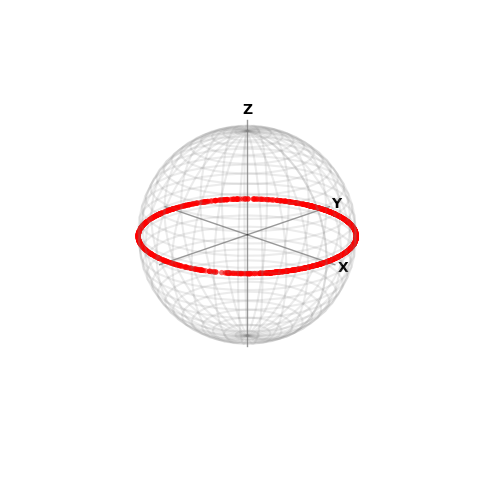

In [118]:
import numpy as np
import matplotlib.pyplot as plt


def plot_bloch_sphere_scatter(expval_x, expval_y, expval_z):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection="3d")

    # Draw the wireframe sphere
    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 30)
    x_sphere = np.outer(np.cos(u), np.sin(v))
    y_sphere = np.outer(np.sin(u), np.sin(v))
    z_sphere = np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color="gray", alpha=0.15)

    # Draw the X, Y, Z axes line spans
    ax.plot([-1.1, 1.1], [0, 0], [0, 0], color="k", lw=1, alpha=0.4)
    ax.plot([0, 0], [-1.1, 1.1], [0, 0], color="k", lw=1, alpha=0.4)
    ax.plot([0, 0], [0, 0], [-1.1, 1.1], color="k", lw=1, alpha=0.4)

    # Better Label Placement adjusted for the new camera angle
    ax.text(1.2, 0, 0, "X", ha="center", va="center", fontweight="bold")
    ax.text(0, 1.2, 0, "Y", ha="center", va="center", fontweight="bold")
    ax.text(0, 0, 1.2, "Z", ha="center", va="center", fontweight="bold")

    # Plot the expectation values
    ax.scatter(
        expval_x, expval_y, expval_z, color="red", s=15, alpha=0.6, edgecolors="none"
    )

    # --- THE FIX: Force standard Bloch Sphere Perspective ---
    # elev=20 tilts the sphere slightly so you can see the top/equator
    # azim=-45 rotates X and Y to look like standard textbook diagrams
    ax.view_init(elev=20, azim=-45)

    # Clean up the axes and aspect ratio
    ax.set_box_aspect([1, 1, 1])
    ax.set_axis_off()

    return fig, ax


# Example usage:
plot_bloch_sphere_scatter(expval_x, expval_y, expval_z)
plt.show()

In [119]:
expval_x.mean(), expval_y.mean(), expval_z.mean()

(Array(0.13869741, dtype=float64),
 Array(0.08657307, dtype=float64),
 Array(0., dtype=float64))

In [120]:
expval_x.mean() + expval_y.mean() + expval_z.mean()

Array(0.22527047, dtype=float64)